# 线性神经网络总结

本notebook整理了《动手学深度学习》第三章的核心概念和代码，涵盖线性回归、Softmax回归和图像分类数据集。

## 本章结构
1. **线性回归** — 理论基础、损失函数、优化算法
2. **线性回归实现** — 从零实现 vs 简洁实现
3. **Softmax回归** — 分类问题、softmax运算、交叉熵损失
4. **图像分类数据集** — Fashion-MNIST数据加载与可视化

## 一、线性回归（Linear Regression）

线性回归是最简单且最流行的回归工具，用于预测**连续数值**（如房价、销量）。

### 1.1 线性模型

**核心公式**：给定$d$个特征，预测值为：

$$\hat{y} = w_1 x_1 + w_2 x_2 + \cdots + w_d x_d + b = \mathbf{w}^\top \mathbf{x} + b$$

- **权重（weight）** $\mathbf{w}$：每个特征对预测的影响程度
- **偏置（bias）** $b$：所有特征为0时的预测值（截距）
- **仿射变换（affine transformation）**：线性变换 + 平移

**批量表示**：$n$个样本，$d$个特征

$$\hat{\mathbf{y}} = \mathbf{X}\mathbf{w} + b, \quad \mathbf{X} \in \mathbb{R}^{n \times d}$$

### 1.2 损失函数（Loss Function）

**均方误差（Mean Squared Error, MSE）**：

$$L(\mathbf{w}, b) = \frac{1}{n} \sum_{i=1}^{n} \frac{1}{2}(\hat{y}^{(i)} - y^{(i)})^2$$

- 常数$\frac{1}{2}$是为了求导后系数为1
- 目标：找到$\mathbf{w}^*, b^* = \arg\min_{\mathbf{w}, b} L(\mathbf{w}, b)$

### 1.3 解析解（Analytical Solution）

线性回归存在闭式解：

$$\mathbf{w}^* = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

**优点**：直接计算，无需迭代
**局限**：仅适用于简单问题，深度学习中通常不存在解析解

### 1.4 随机梯度下降（Stochastic Gradient Descent, SGD）

当不存在解析解时，使用**梯度下降**迭代更新参数：

$$(\mathbf{w}, b) \leftarrow (\mathbf{w}, b) - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} \partial_{(\mathbf{w},b)} l^{(i)}(\mathbf{w}, b)$$

- **学习率（learning rate）** $\eta$：控制更新步长
- **批量大小（batch size）** $|\mathcal{B}|$：每次更新使用的样本数
- **超参数（hyperparameter）**：需要手动设定，不在训练中更新

### 1.5 正态分布与平方损失

**为什么用平方误差？** 假设噪声服从正态分布：

$$y = \mathbf{w}^\top \mathbf{x} + b + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)$$

通过**极大似然估计（Maximum Likelihood Estimation, MLE）**，最小化均方误差等价于最大化似然函数。

### 1.6 神经网络表示

线性回归可视为**单层神经网络**：
- 输入层：$d$个特征
- 输出层：1个神经元
- **全连接层（fully-connected layer）**：每个输入都与输出相连

## 二、线性回归实现

### 2.1 从零实现（Scratch Implementation）

训练过程的核心要素：
1. **数据流水线**：生成/读取数据、小批量采样
2. **模型**：定义前向传播
3. **损失函数**：均方误差
4. **优化算法**：小批量SGD

In [ ]:
import torch
import random

# 1. 生成数据集
def synthetic_data(w, b, num_examples):
    """生成 y = Xw + b + 噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)
print(f"features shape: {features.shape}, labels shape: {labels.shape}")

In [ ]:
# 2. 读取数据集（小批量采样）
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)  # 随机打乱
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i:min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

# 3. 初始化模型参数
w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

# 4. 定义模型
def linreg(X, w, b):
    """线性回归模型: y = Xw + b"""
    return torch.matmul(X, w) + b

# 5. 定义损失函数
def squared_loss(y_hat, y):
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

# 6. 定义优化算法
def sgd(params, lr, batch_size):
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()  # 清除梯度

In [ ]:
# 7. 训练
lr = 0.03
num_epochs = 3
batch_size = 10
net = linreg
loss = squared_loss

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)  # 小批量损失
        l.sum().backward()          # 反向传播
        sgd([w, b], lr, batch_size) # 更新参数
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

print(f'\nw的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

### 2.2 简洁实现（Concise Implementation）

使用PyTorch的高级API（`nn`模块）可以更简洁地实现：

```python
from torch import nn

# 定义模型
net = nn.Sequential(nn.Linear(2, 1))

# 初始化参数
net[0].weight.data.normal_(0, 0.01)
net[0].bias.data.fill_(0)

# 定义损失函数
loss = nn.MSELoss()

# 定义优化器
trainer = torch.optim.SGD(net.parameters(), lr=0.03)

# 训练
for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X), y)
        trainer.zero_grad()
        l.backward()
        trainer.step()
```

## 三、Softmax回归（Softmax Regression）

Softmax回归用于**分类问题**，预测样本属于哪个类别（如图像分类）。

### 3.1 分类问题

**标签表示**：使用**独热编码（one-hot encoding）**
- 类别"猫"→ $(1, 0, 0)$
- 类别"鸡"→ $(0, 1, 0)$
- 类别"狗"→ $(0, 0, 1)$

**网络架构**：
- 输入：$d$个特征
- 输出：$q$个类别
- 权重矩阵：$\mathbf{W} \in \mathbb{R}^{d \times q}$
- 偏置：$\mathbf{b} \in \mathbb{R}^{1 \times q}$

### 3.2 Softmax运算

线性层输出 $\mathbf{o}$（未规范化的预测/logit）不能直接作为概率（可能为负，总和不为1）。

**Softmax函数**将logit转换为概率分布：

$$\hat{y}_j = \frac{\exp(o_j)}{\sum_{k=1}^{q} \exp(o_k)}$$

性质：
- 输出非负：$\hat{y}_j \geq 0$
- 总和为1：$\sum_j \hat{y}_j = 1$
- 保持大小顺序：$\arg\max_j \hat{y}_j = \arg\max_j o_j$

**小批量矢量化**：
$$\mathbf{O} = \mathbf{X}\mathbf{W} + \mathbf{b}, \quad \hat{\mathbf{Y}} = \mathrm{softmax}(\mathbf{O})$$

### 3.3 交叉熵损失（Cross-Entropy Loss）

分类问题的损失函数，基于**最大似然估计**：

$$l(\mathbf{y}, \hat{\mathbf{y}}) = -\sum_{j=1}^{q} y_j \log \hat{y}_j$$

由于 $\mathbf{y}$ 是独热编码，只有正确类别的项非零，简化为：

$$l = -\log \hat{y}_{\text{正确类别}}$$

**梯度**：$\partial_{o_j} l = \mathrm{softmax}(\mathbf{o})_j - y_j$（预测概率与真实标签之差）

### 3.4 信息论视角

- **熵（entropy）**：$H[P] = -\sum_j P(j) \log P(j)$，编码所需的信息量
- **交叉熵（cross-entropy）**：$H(P, Q) = -\sum_j P(j) \log Q(j)$，用$Q$编码$P$的代价
- **最小化交叉熵** = 最大化似然 = 最小化传达标签的"惊异"

### 3.5 Softmax回归从零实现

#### 3.5.1 初始化模型参数

- 输入：784维（28×28像素展平）
- 输出：10个类别
- 权重矩阵 W：(784, 10)
- 偏置 b：(10,)

In [ ]:
import torch
from IPython import display

# ============ 3.5.1 初始化模型参数 ============
num_inputs = 784
num_outputs = 10

W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

print(f'权重W shape: {W.shape}')  # (784, 10)
print(f'偏置b shape: {b.shape}')  # (10,)

# ============ 3.5.2 定义Softmax运算 ============
def softmax(X):
    """Softmax运算：将logit转换为概率分布
    步骤：1.对每个项求幂 2.对每一行求和得到归一化常数 3.每行除以归一化常数
    """
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdim=True)  # 按行求和，保持维度
    return X_exp / partition  # 广播机制

# 测试softmax
X_test = torch.normal(0, 1, (2, 5))
X_prob = softmax(X_test)
print(f'\nSoftmax测试:')
print(f'输入:\n{X_test}')
print(f'输出（每行和为1）:\n{X_prob}')
print(f'每行求和: {X_prob.sum(1)}')  # 应该都是1.0

# ============ 3.5.3 定义模型 ============
def net(X):
    """Softmax回归模型：展平输入 → 线性变换 → Softmax"""
    return softmax(torch.matmul(X.reshape((-1, W.shape[0])), W) + b)

# ============ 3.5.4 定义交叉熵损失函数 ============
def cross_entropy(y_hat, y):
    """交叉熵损失：-log(正确类别的预测概率)
    y_hat: 预测概率 (batch_size, num_classes)
    y: 真实标签 (batch_size,)
    """
    return -torch.log(y_hat[range(len(y_hat)), y])

# 测试交叉熵
y_test = torch.tensor([0, 2])  # 2个样本的真实标签
y_hat_test = torch.tensor([[0.1, 0.3, 0.6], [0.3, 0.2, 0.5]])  # 预测概率
print(f'\n交叉熵测试:')
print(f'真实标签: {y_test}')
print(f'预测概率:\n{y_hat_test}')
print(f'选择正确类别的概率: {y_hat_test[[0, 1], y_test]}')  # [0.1, 0.5]
print(f'交叉熵损失: {cross_entropy(y_hat_test, y_test)}')  # [-log(0.1), -log(0.5)]

# ============ 3.5.5 分类精度 ============
def accuracy(y_hat, y):
    """计算预测正确的数量"""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)  # 取最大概率的索引作为预测类别
    cmp = y_hat.type(y.dtype) == y    # 比较预测和真实标签
    return float(cmp.type(y.dtype).sum())

# 测试精度
print(f'\n精度测试:')
print(f'预测类别: {y_hat_test.argmax(axis=1)}')  # [2, 2]
print(f'真实标签: {y_test}')                      # [0, 2]
print(f'正确数量: {accuracy(y_hat_test, y_test)}')  # 1
print(f'精度: {accuracy(y_hat_test, y_test) / len(y_test)}')  # 0.5

class Accumulator:
    """在n个变量上累加"""
    def __init__(self, n):
        self.data = [0.0] * n

    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]

    def reset(self):
        self.data = [0.0] * len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

def evaluate_accuracy(net, data_iter):
    """计算在指定数据集上模型的精度"""
    if isinstance(net, torch.nn.Module):
        net.eval()  # 将模型设置为评估模式
    metric = Accumulator(2)  # 正确预测数、预测总数
    with torch.no_grad():
        for X, y in data_iter:
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

# ============ 3.5.6 训练函数 ============
class Animator:
    """在动画中绘制数据"""
    def __init__(self, xlabel=None, ylabel=None, legend=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 fmts=('-', 'm--', 'g-.', 'r:'), nrows=1, ncols=1,
                 figsize=(3.5, 2.5)):
        if legend is None:
            legend = []
        self.fig, self.axes = plt.subplots(nrows, ncols, figsize=figsize)
        if nrows * ncols == 1:
            self.axes = [self.axes, ]
        self.config_axes = lambda: None  # 简化版
        self.X, self.Y, self.fmts = None, None, fmts

    def add(self, x, y):
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        if not self.X:
            self.X = [[] for _ in range(n)]
        if not self.Y:
            self.Y = [[] for _ in range(n)]
        for i, (a, b) in enumerate(zip(x, y)):
            if a is not None and b is not None:
                self.X[i].append(a)
                self.Y[i].append(b)

def train_epoch_ch3(net, train_iter, loss, updater):
    """训练模型一个迭代周期"""
    if isinstance(net, torch.nn.Module):
        net.train()
    metric = Accumulator(3)  # 训练损失总和、训练准确度总和、样本数
    for X, y in train_iter:
        y_hat = net(X)
        l = loss(y_hat, y)
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.mean().backward()
            updater.step()
        else:
            l.sum().backward()
            updater(X.shape[0])
        metric.add(float(l.sum()), accuracy(y_hat, y), y.numel())
    return metric[0] / metric[2], metric[1] / metric[2]

def train_ch3(net, train_iter, test_iter, loss, num_epochs, updater):
    """训练模型（见第3章）"""
    train_losses, train_accs, test_accs = [], [], []
    for epoch in range(num_epochs):
        train_metrics = train_epoch_ch3(net, train_iter, loss, updater)
        test_acc = evaluate_accuracy(net, test_iter)
        train_losses.append(train_metrics[0])
        train_accs.append(train_metrics[1])
        test_accs.append(test_acc)
        print(f'Epoch {epoch+1}/{num_epochs}: '
              f'loss={train_metrics[0]:.4f}, '
              f'train_acc={train_metrics[1]:.4f}, '
              f'test_acc={test_acc:.4f}')
    return train_losses, train_accs, test_accs

# ============ 3.5.7 训练模型 ============
import matplotlib.pyplot as plt

# 加载Fashion-MNIST数据
import torchvision
from torch.utils import data
from torchvision import transforms

trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=True)

batch_size = 256
train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True)
test_iter = data.DataLoader(mnist_test, batch_size, shuffle=False)

# 重新初始化参数
W = torch.normal(0, 0.01, size=(num_inputs, num_outputs), requires_grad=True)
b = torch.zeros(num_outputs, requires_grad=True)

# 训练
lr = 0.1
num_epochs = 10

def updater(batch_size):
    return d2l.sgd([W, b], lr, batch_size)

# 注意：需要导入d2l
import sys
sys.path.append('..')
from d2l import torch as d2l

print('开始训练...')
train_losses, train_accs, test_accs = train_ch3(
    net, train_iter, test_iter, cross_entropy, num_epochs, updater)

# 绘制训练曲线
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.plot(range(1, num_epochs+1), train_losses, 'b-o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')

ax2.plot(range(1, num_epochs+1), train_accs, 'b-o', label='Train')
ax2.plot(range(1, num_epochs+1), test_accs, 'r-s', label='Test')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy')
ax2.legend()
plt.tight_layout()
plt.show()

## 四、图像分类数据集（Fashion-MNIST）

### 4.1 Fashion-MNIST简介

MNIST数据集是图像分类中广泛使用的数据集，但作为基准**过于简单**。
我们使用类似但更复杂的**Fashion-MNIST**数据集。

**数据集特点**：
- 10个类别的服装图像
- 每个类别：训练集6000张 + 测试集1000张
- 总计：训练集60000张 + 测试集10000张
- 图像大小：28×28像素，灰度图（通道数=1）

**10个类别**：

| 标签 | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|------|---|---|---|---|---|---|---|---|---|---|
| 类别 | T恤 | 裤子 | 套衫 | 连衣裙 | 外套 | 凉鞋 | 衬衫 | 运动鞋 | 包 | 短靴 |

### 4.2 加载数据集

In [11]:
import torch
import torchvision
from torch.utils import data
from torchvision import transforms

# 通过ToTensor将图像从PIL转为32位浮点数，并除以255归一化到[0,1]
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=True)

print(f'训练集大小: {len(mnist_train)}')
print(f'测试集大小: {len(mnist_test)}')
print(f'单张图片shape: {mnist_train[0][0].shape}')  # (通道数, 高, 宽)
print(f'第一个样本标签: {mnist_train[0][1]}')

100.0%
100.0%
100.0%
100.0%


训练集大小: 60000
测试集大小: 10000
单张图片shape: torch.Size([1, 28, 28])
第一个样本标签: 9


### 4.3 数据集的结构

每个样本是一个元组 `(image, label)`：
- `image`：形状为 `(1, 28, 28)` 的张量（1通道，28×28像素）
- `label`：0-9的整数标签

**图像形状表示**：高度$h$像素 × 宽度$w$像素 → 记为 $h \times w$ 或 $(h, w)$

In [12]:
# 查看数据结构
image, label = mnist_train[0]
print(f'图像形状: {image.shape}')      # (1, 28, 28)
print(f'图像类型: {image.dtype}')        # torch.float32
print(f'像素值范围: [{image.min():.1f}, {image.max():.1f}]')  # [0.0, 1.0]
print(f'标签: {label}')                  # 整数 0-9
print(f'标签类型: {type(label)}')

图像形状: torch.Size([1, 28, 28])
图像类型: torch.float32
像素值范围: [0.0, 1.0]
标签: 9
标签类型: <class 'int'>


### 4.4 标签与类别名称的映射

In [13]:
def get_fashion_mnist_labels(labels):
    """返回Fashion-MNIST数据集的文本标签"""
    text_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
                   'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [text_labels[int(i)] for i in labels]

# 测试
print(get_fashion_mnist_labels([0, 1, 2, 3, 4]))
print(get_fashion_mnist_labels([5, 6, 7, 8, 9]))

['t-shirt', 'trouser', 'pullover', 'dress', 'coat']
['sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']


### 4.5 可视化样本

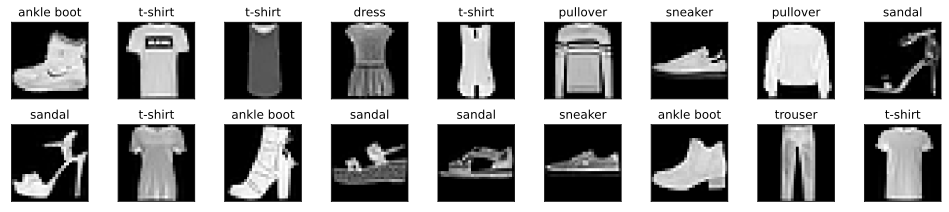

In [14]:
import matplotlib.pyplot as plt

def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """绘制图像列表"""
    figsize = (num_cols * scale, num_rows * scale)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            ax.imshow(img.numpy(), cmap='gray')  # 灰度图
        else:
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    plt.tight_layout()
    plt.show()

# 取18个样本展示
X, y = next(iter(data.DataLoader(mnist_train, batch_size=18)))
show_images(X.reshape(18, 28, 28), 2, 9, titles=get_fashion_mnist_labels(y))

### 4.6 读取小批量数据

使用PyTorch的 `DataLoader` 来读取小批量数据：

- `batch_size`：每批读取的样本数
- `shuffle=True`：随机打乱样本（训练集需要）
- `num_workers`：使用多进程读取数据（加速）

In [15]:
batch_size = 256

def get_dataloader_workers():
    """使用4个进程来读取数据"""
    return 4

train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True,
                             num_workers=get_dataloader_workers())

# 测试读取速度
import time
start = time.time()
for X, y in train_iter:
    continue
print(f'读取一遍训练集耗时: {time.time() - start:.2f} 秒')
print(f'每批数据shape: {X.shape}')  # (batch_size, 1, 28, 28)
print(f'每批标签shape: {y.shape}')  # (batch_size,)

读取一遍训练集耗时: 14.53 秒
每批数据shape: torch.Size([96, 1, 28, 28])
每批标签shape: torch.Size([96])


### 4.7 整合：完整的数据加载函数

将所有组件整合成一个函数，方便后续章节调用：

In [ ]:
def load_data_fashion_mnist(batch_size, resize=None):
    """下载Fashion-MNIST数据集，然后将其加载到内存中
    
    Args:
        batch_size: 每批样本数
        resize: 可选，将图像调整为指定大小
    
    Returns:
        train_iter: 训练集数据迭代器
        test_iter: 测试集数据迭代器
    """
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    
    mnist_train = torchvision.datasets.FashionMNIST(
        root="../data", train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(
        root="../data", train=False, transform=trans, download=True)
    
    return (data.DataLoader(mnist_train, batch_size, shuffle=True,
                            num_workers=get_dataloader_workers()),
            data.DataLoader(mnist_test, batch_size, shuffle=False,
                            num_workers=get_dataloader_workers()))

# 测试：默认28x28
train_iter, test_iter = load_data_fashion_mnist(32)
for X, y in train_iter:
    print(f'默认大小 - X: {X.shape}, y: {y.shape}')
    break

# 测试：调整为64x64
train_iter, test_iter = load_data_fashion_mnist(32, resize=64)
for X, y in train_iter:
    print(f'调整后 - X: {X.shape}, y: {y.shape}')
    break

## 五、本章核心知识总结

### 线性回归 vs Softmax回归

| 对比项 | 线性回归 | Softmax回归 |
|--------|----------|-------------|
| 任务类型 | 回归（预测数值） | 分类（预测类别） |
| 输出 | 标量 $\hat{y}$ | 概率分布 $\hat{\mathbf{y}}$ |
| 输出层 | 1个神经元 | $q$个神经元 |
| 损失函数 | 均方误差（MSE） | 交叉熵（Cross-Entropy） |
| 激活函数 | 无 | Softmax |

### Fashion-MNIST数据集

| 属性 | 值 |
|------|----|
| 类别数 | 10 |
| 训练集 | 60000张 |
| 测试集 | 10000张 |
| 图像大小 | 28×28像素 |
| 通道数 | 1（灰度图） |
| 像素值范围 | [0, 1]（归一化后） |

### 关键术语速查表

| 术语 | 英文 | 核心含义 |
|------|------|----------|
| 权重 | weight | 特征对预测的影响 |
| 偏置 | bias | 截距项 |
| 损失函数 | loss function | 衡量预测与真实差距 |
| 均方误差 | mean squared error | 回归损失：$\frac{1}{2}(\hat{y}-y)^2$ |
| 解析解 | analytical solution | 直接公式计算的解 |
| 梯度下降 | gradient descent | 沿梯度方向更新参数 |
| 学习率 | learning rate | 控制更新步长 |
| 批量大小 | batch size | 每次更新的样本数 |
| 超参数 | hyperparameter | 手动设定，不在训练中更新 |
| 独热编码 | one-hot encoding | 类别用向量表示 |
| Softmax | softmax | 将logit转为概率 |
| 交叉熵 | cross-entropy | 分类损失函数 |
| 准确率 | accuracy | 正确预测比例 |
| 全连接层 | fully-connected layer | 每个输入与输出相连 |
| 迭代周期 | epoch | 遍历整个数据集一次 |
| 数据迭代器 | data iterator | 按批次加载数据的工具 |
| 数据增强 | data augmentation | 通过变换增加训练数据 |
| ToTensor | ToTensor | PIL图像转为张量并归一化 |